# Privugger Pyro SVI Example

This notebook demonstrates how to use Privugger with the Pyro backend for Stochastic Variational Inference (SVI) to analyze information leakage.

In [3]:
import os
import sys
import numpy as np
import torch
import pyro
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # For creating DataFrames from posterior samples

# Make sure we can import the local privugger package
sys.path.append('../../..')  # Add parent directory to path

import privugger as pv

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

## Average Function

We'll be using an average function as our anonymization mechanism. This is a simple function that calculates the average of a dataset.

## Utility Functions for Visualization and Metrics

In [4]:
pv.reset()
pyro.clear_param_store()

def avg(ages):
    return (ages.sum() / len(ages))

# Simple prior distribution
age = pv.Normal("age", mu=35.0, std=2.0, num_elements=100)
 
# Dataset and program
ds = pv.Dataset(input_specs=[age])


prog = pv.Program("output", dataset=ds, output_type=pv.Float, function=avg)


# Let's add an observation
prog.add_observation('output==44', precision=0.1)

print("Running SVI with Pyro backend...")
trace = pv.infer(prog, draws=1000, method="pyro", svi_steps=1500, svi_lr=0.01)

Running SVI with Pyro backend...
Observations detected, running SVI with 3000 steps
Step 0/3000 - Loss: 0.0000
Step 100/3000 - Loss: 0.2414
Step 200/3000 - Loss: 0.3354
Step 300/3000 - Loss: 0.2144
Step 400/3000 - Loss: 0.0433
Step 500/3000 - Loss: 0.1160
Step 600/3000 - Loss: 0.1446
Step 700/3000 - Loss: 0.4899
Step 800/3000 - Loss: 0.5314
Step 900/3000 - Loss: 0.0182
Step 1000/3000 - Loss: 0.7769
Step 1100/3000 - Loss: 0.0619
Step 1200/3000 - Loss: 0.0631
Step 1300/3000 - Loss: 0.1015
Step 1400/3000 - Loss: 0.0444
Step 1500/3000 - Loss: 0.6638
Step 1600/3000 - Loss: 0.1005
Step 1700/3000 - Loss: 0.1732
Step 1800/3000 - Loss: 0.2277
Step 1900/3000 - Loss: 0.3569
Step 2000/3000 - Loss: 0.4212
Step 2100/3000 - Loss: 0.0616
Step 2200/3000 - Loss: 0.1100
Step 2300/3000 - Loss: 0.1061
Step 2400/3000 - Loss: 0.1892
Step 2500/3000 - Loss: 0.2051
Step 2600/3000 - Loss: 0.0703
Step 2700/3000 - Loss: 0.3237
Step 2800/3000 - Loss: 0.0867
Step 2900/3000 - Loss: 0.2129


## 1. Privugger with Pyro SVI Backend

Now we'll implement a proper example using Privugger's Pyro backend with SVI.

In [5]:
# Examine the structure of the posterior
print("Available posterior variables:")
print(trace.posterior.data_vars)

Available posterior variables:
Data variables:
    age      (chain, draw, age_dim_0) float32 38.16 34.97 36.39 ... 33.59 38.58
    output   (chain, draw) float32 35.62 35.0 35.13 34.95 ... 34.71 34.84 35.3


c:\Users\tommc\anaconda3\envs\privugger\Lib\site-packages\arviz\plots\plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (100) in plot_posterior, generating only 40 plots
  warnings.warn(


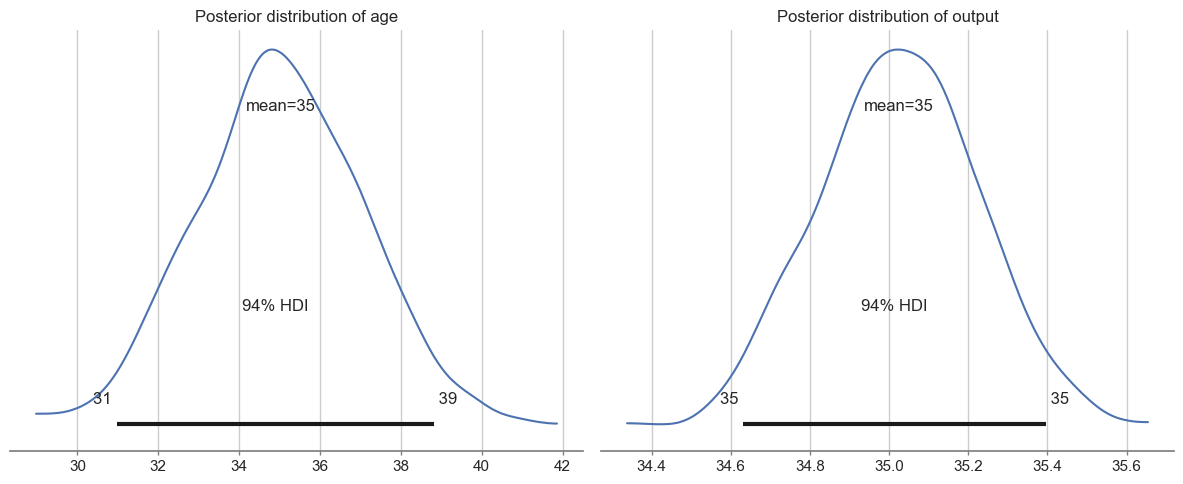

In [6]:
# Basic posterior plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot the posterior distribution for age
az.plot_posterior(trace, var_names=["age"], ax=ax[0])
ax[0].set_title("Posterior distribution of age")

# Plot the posterior distribution for output
az.plot_posterior(trace, var_names=["output"], ax=ax[1])
ax[1].set_title("Posterior distribution of output")

plt.tight_layout()
plt.show()

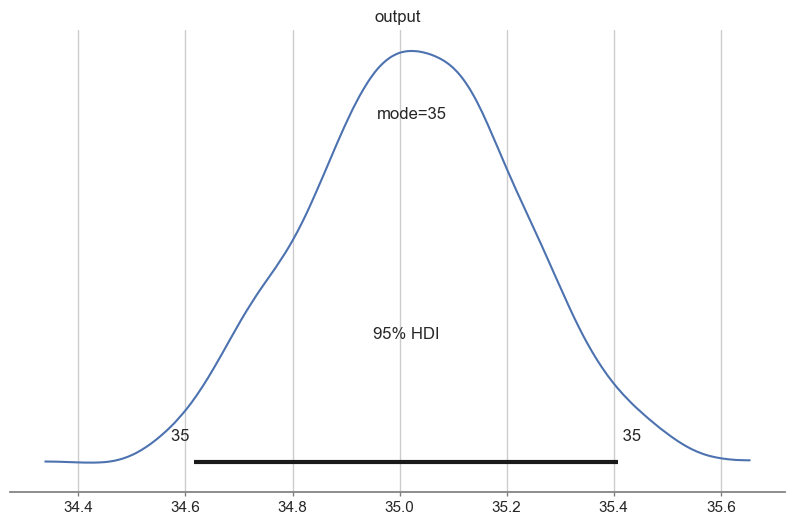

In [7]:
az.plot_posterior(trace, var_names=['output'], hdi_prob=.95, point_estimate='mode'); # plot the inferred distribution of the output

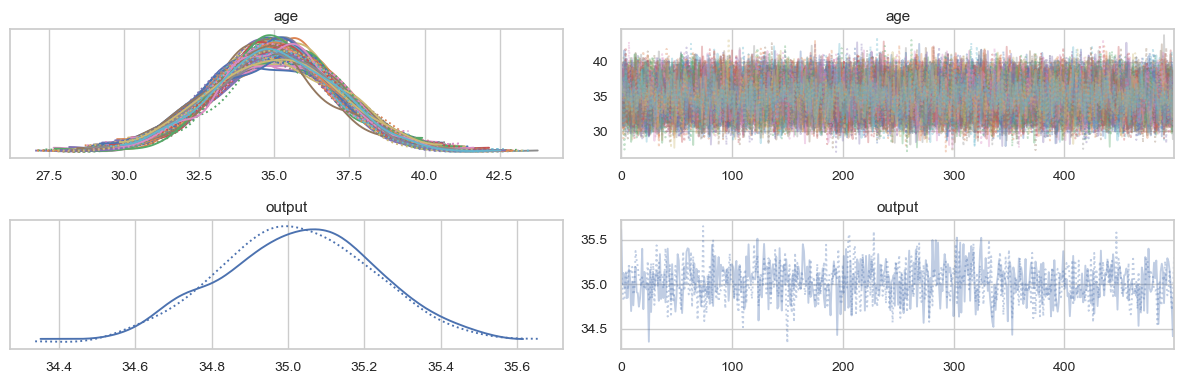

In [8]:
# Plot trace
az.plot_trace(trace)
plt.tight_layout()
plt.show()

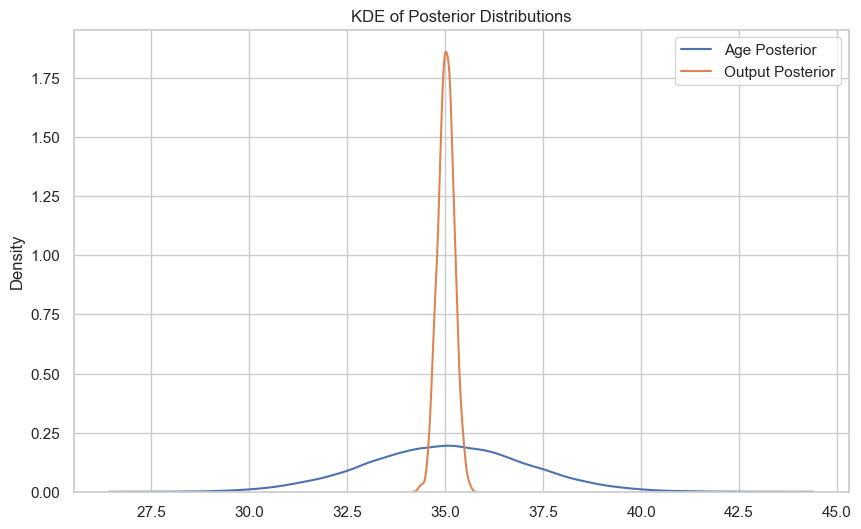

In [9]:
# Kernel Density Estimate plot for a more detailed view
plt.figure(figsize=(10, 6))
sns.kdeplot(trace.posterior.age.values.flatten(), label="Age Posterior")
sns.kdeplot(trace.posterior.output.values.flatten(), label="Output Posterior")
plt.title("KDE of Posterior Distributions")
plt.legend()
plt.show()